In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone
from dateutil.relativedelta import relativedelta
import time
from google.colab import drive
import numpy as np

# ====== GOOGLE DRIVE ======
drive.mount('/content/drive', force_remount=True)
OUT_CSV = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota.csv"

# ====== CONFIGURATION ======
LAT = 5.172323
LON = -73.632071
COMMUNITY = "RE"
PARAMS = ["ALLSKY_SFC_SW_DWN", "T2M"]
TIME_STANDARD = "UTC"

# Dates (Last 11 years)
today_utc = datetime.now(timezone.utc).date()
end_date = today_utc - timedelta(days=1)
start_date = end_date - relativedelta(years=11) + timedelta(days=1)


def build_url():
    return "https://power.larc.nasa.gov/api/temporal/hourly/point"

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Colab-NASA-POWER/1.0 (contact: your_email@example.com)"
})

def fetch_year_chunk(year_start: datetime, year_end: datetime, lat: float, lon: float):
    url = build_url()
    params = {
        "parameters": ",".join(PARAMS),
        "community": COMMUNITY,
        "longitude": lon,
        "latitude": lat,
        "start": year_start.strftime("%Y%m%d"),
        "end": year_end.strftime("%Y%m%d"),
        "format": "JSON",
        "time-standard": TIME_STANDARD,
    }
    r = SESSION.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    param_block = js.get("properties", {}).get("parameter", {})
    if not param_block:
        return pd.DataFrame(columns=["datetime_utc"] + PARAMS)

    all_keys = set()
    for p in PARAMS:
        all_keys.update(param_block.get(p, {}).keys())

    records = []
    for key in sorted(all_keys):
        row = {"datetime_utc": pd.to_datetime(key, format="%Y%m%d%H", utc=True)}
        for p in PARAMS:
            val = param_block.get(p, {}).get(key, None)

            if val in (-999, -999.0, -9999, -9999.0):
                val = None
            row[p] = val
        records.append(row)

    df_year = pd.DataFrame.from_records(records)

    for p in PARAMS:
        df_year[p] = pd.to_numeric(df_year[p], errors="coerce")

    return df_year

def chunk_years(start_dt: datetime, end_dt: datetime):
    chunks = []
    y0, y1 = start_dt.year, end_dt.year
    for y in range(y0, y1 + 1):
        s = datetime(y, 1, 1, tzinfo=timezone.utc)
        e = datetime(y, 12, 31, tzinfo=timezone.utc)
        if y == y0 and s < start_dt: s = start_dt
        if y == y1 and e > end_dt: e = end_dt
        chunks.append((s, e))
    return chunks

all_frames = []
year_chunks = chunk_years(
    datetime.combine(start_date, datetime.min.time(), tzinfo=timezone.utc),
    datetime.combine(end_date, datetime.min.time(), tzinfo=timezone.utc),
)

print(f"Descargando NASA POWER horario {start_date} → {end_date} (UTC)")
for (ys, ye) in year_chunks:
    print(f"- Año {ys.year}: {ys.date()} → {ye.date()} ...", end="", flush=True)
    for attempt in range(3):
        try:
            df_year = fetch_year_chunk(ys, ye, LAT, LON)
            print(f" OK ({len(df_year)} filas)")
            if len(df_year):
                all_frames.append(df_year)
            break
        except Exception as e:
            print(f" fallo intento {attempt+1}: {e}", end="")
            if attempt < 2:
                print(" → reintentando...")
                time.sleep(2 + attempt*2)
            else:
                print(" → omitiendo este tramo.")
    time.sleep(0.5)

if not all_frames:
    raise RuntimeError("No se obtuvieron datos de la API. Revisa lat/lon, fechas o conexión.")

df = (
    pd.concat(all_frames, ignore_index=True)
      .drop_duplicates(subset=["datetime_utc"])
      .sort_values("datetime_utc")
)


df["datetime_bogota"] = df["datetime_utc"].dt.tz_convert("America/Bogota")


df = df.rename(columns={"ALLSKY_SFC_SW_DWN": "irradiancia_kWh_m2_h", "T2M": "t2m_C"})


df["ghi_w_m2"] = df["irradiancia_kWh_m2_h"] * 1000.0


df = df[["datetime_utc", "datetime_bogota", "irradiancia_kWh_m2_h", "ghi_w_m2", "t2m_C"]]


df.to_csv(OUT_CSV, index=False, float_format="%.3f")
print(f"✅ CSV guardado en tu Google Drive: {OUT_CSV} (filas: {len(df)})")


print("Rango UTC:", df["datetime_utc"].min(), "→", df["datetime_utc"].max())
print("Nulos por columna:\n", df.isna().sum())



Mounted at /content/drive
Descargando NASA POWER horario 2014-11-04 → 2025-11-03 (UTC)
- Año 2014: 2014-11-04 → 2014-12-31 ... OK (1392 filas)
- Año 2015: 2015-01-01 → 2015-12-31 ... OK (8760 filas)
- Año 2016: 2016-01-01 → 2016-12-31 ... OK (8784 filas)
- Año 2017: 2017-01-01 → 2017-12-31 ... OK (8760 filas)
- Año 2018: 2018-01-01 → 2018-12-31 ... OK (8760 filas)
- Año 2019: 2019-01-01 → 2019-12-31 ... OK (8760 filas)
- Año 2020: 2020-01-01 → 2020-12-31 ... OK (8784 filas)
- Año 2021: 2021-01-01 → 2021-12-31 ... OK (8760 filas)
- Año 2022: 2022-01-01 → 2022-12-31 ... OK (8760 filas)
- Año 2023: 2023-01-01 → 2023-12-31 ... OK (8760 filas)
- Año 2024: 2024-01-01 → 2024-12-31 ... OK (8784 filas)
- Año 2025: 2025-01-01 → 2025-11-03 ... OK (7368 filas)
✅ CSV guardado en tu Google Drive: /content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota.csv (filas: 96432)
Rango UTC: 2014-11-04 00:00:00+00:00 → 2025-11-03 23:00:00+00:00
Nulos por columna:
 datetime_utc               0
datet

In [ ]:
# === Limpieza estadística robusta conservando tiempo y aplicando cuantiles ===

import pandas as pd
import numpy as np

CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota.csv"
OUT_CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clean.csv"
COLS = ["irradiancia_kWh_m2_h", "t2m_C"]
Q_LOW, Q_HIGH = 0.001, 0.999   # 0.1% y 99.9%

# Cargar
df = pd.read_csv(CSV_PATH)

# Detectar columna de tiempo
time_col = "datetime_bogota" if "datetime_bogota" in df.columns else (
    "datetime_utc" if "datetime_utc" in df.columns else None
)
if time_col is None:
    raise KeyError("No encuentro columna de tiempo ('datetime_bogota' o 'datetime_utc').")

# 2) Normalizar texto -> número (quita espacios, cambia coma decimal por punto)
for c in COLS:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Reemplazar códigos de 'sin dato' y eliminar nulos
df[COLS] = df[COLS].replace([-999, -999.0, -9999, -9999.0], np.nan)
n_ini = len(df)
df = df.dropna(subset=COLS+[time_col]).copy()
print(f"NaN eliminados: {n_ini - len(df)} filas")

# Asegurar datetime
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# Cuantiles por columna (solo en las columnas numéricas)
lo_irr, hi_irr = df["irradiancia_kWh_m2_h"].quantile([Q_LOW, Q_HIGH])
lo_t2m,  hi_t2m = df["t2m_C"].quantile([Q_LOW, Q_HIGH])

# Filtro estadístico
mask = (
    (df["irradiancia_kWh_m2_h"].between(lo_irr, hi_irr)) &
    (df["t2m_C"].between(lo_t2m, hi_t2m))
)
df_clean = df[mask].copy()
print(f"Outliers eliminados por cuantiles: {len(df) - len(df_clean)} filas")

print(f"✅ Dataset limpio: {len(df_clean)} filas (de {n_ini} originales)")

df_clean.to_csv(OUT_CSV_CLEAN, index=False)
print(f"📂 Archivo limpio guardado en: {OUT_CSV_CLEAN}")

print("Rangos finales:")
print("irradiancia_kWh_m2_h:", float(df_clean['irradiancia_kWh_m2_h'].min()), "→", float(df_clean['irradiancia_kWh_m2_h'].max()))
print("t2m_C:", float(df_clean['t2m_C'].min()), "→", float(df_clean['t2m_C'].max()))




NaN eliminados: 2280 filas
Outliers eliminados por cuantiles: 284 filas
✅ Dataset limpio: 93868 filas (de 96432 originales)
📂 Archivo limpio guardado en: /content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clean.csv
Rangos finales:
irradiancia_kWh_m2_h: 0.0 → 976.15
t2m_C: 6.74 → 21.85


k=2: DB=0.8511  |  0.23s
k=3: DB=0.6260  |  0.20s
k=4: DB=0.7777  |  0.33s
k=5: DB=0.7413  |  0.34s
k=6: DB=0.8479  |  0.38s
k=7: DB=0.8197  |  0.52s
k=8: DB=0.8503  |  0.71s
k=9: DB=0.8570  |  0.71s
k=10: DB=0.9151  |  0.72s
⏱️ Tiempo total: 4.14s

✅ BEST_K (Davies–Bouldin) = 3  |  DB=0.6260  (↓ mejor)


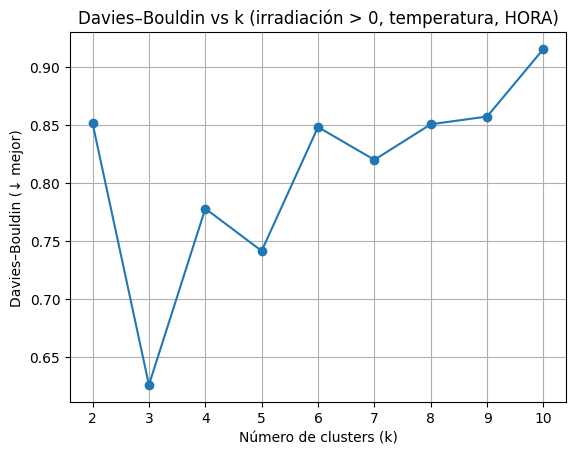

In [ ]:
# === Davies–Bouldin (irradiación > 0, temperatura y HORA directa) + Min–Max  ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, time
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

# --- Configuración ---
CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clean.csv"
K_MIN, K_MAX = 2, 10

SAMPLE_N = None
RANDOM_STATE = 42

# 1) Cargar dataset limpio
df = pd.read_csv(CSV_CLEAN, low_memory=False)

# 2) Detectar nombres + tiempo
cols_ren, cols_nasa = ["irradiancia_kWh_m2_h", "t2m_C"], ["ALLSKY_SFC_SW_DWN", "T2M"]
if set(cols_ren).issubset(df.columns):
    IRR, T2M = cols_ren
elif set(cols_nasa).issubset(df.columns):
    IRR, T2M = cols_nasa
else:
    raise KeyError(f"No encuentro columnas {cols_ren} ni {cols_nasa}. Columnas: {list(df.columns)}")

time_col = "datetime_bogota" if "datetime_bogota" in df.columns else ("datetime_utc" if "datetime_utc" in df.columns else None)
if time_col is None:
    raise KeyError("No encuentro columna de tiempo ('datetime_bogota' o 'datetime_utc').")

# 3) Tipos correctos y filtrado de horas sin sol
df[IRR] = pd.to_numeric(df[IRR], errors="coerce")
df[T2M] = pd.to_numeric(df[T2M], errors="coerce")
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df.dropna(subset=[IRR, T2M, time_col], inplace=True)

# Quitar noche (irradiancia/irradiación = 0) y construir hora directa
df = df[df[IRR] > 0].copy()
df["hour"] = df[time_col].dt.hour.astype(np.int16)

# 4) Matriz de features y normalización Min–Max
FEATURES = [IRR, T2M, "hour"]
X = df[FEATURES].to_numpy(dtype=np.float32)
scaler = MinMaxScaler()
Xs = scaler.fit_transform(X).astype(np.float32)

# 5)Muestreo para acelerar el índice DB
if SAMPLE_N is not None and len(Xs) > SAMPLE_N:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(Xs), size=SAMPLE_N, replace=False)
    Xs_eval = Xs[idx]
else:
    Xs_eval = Xs

# 6) Davies–Bouldin vs K (↓ mejor) — con medidas de tiempo
k_vals, db_scores = [], []
t0 = time.perf_counter()
for k in range(K_MIN, K_MAX + 1):
    t_k = time.perf_counter()
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    # Ajuste y etiquetas (usamos el mismo conjunto para entrenamiento y evaluación del índice)
    labels = km.fit_predict(Xs_eval)
    db = davies_bouldin_score(Xs_eval, labels)
    k_vals.append(k); db_scores.append(db)
    print(f"k={k}: DB={db:.4f}  |  {time.perf_counter() - t_k:.2f}s")
print(f"⏱️ Tiempo total: {time.perf_counter() - t0:.2f}s")

BEST_K = int(k_vals[int(np.argmin(db_scores))])
print(f"\n✅ BEST_K (Davies–Bouldin) = {BEST_K}  |  DB={min(db_scores):.4f}  (↓ mejor)")

# 7) Gráfica
plt.figure()
plt.plot(k_vals, db_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies–Bouldin (↓ mejor)")
plt.title("Davies–Bouldin vs k (irradiación > 0, temperatura, HORA)")
plt.grid(True)
plt.show()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.3 MB/s eta 0:00:00
k=2: Xie–Beni=0.251823  |  t=2.91s
k=3: Xie–Beni=0.085750  |  t=1.57s
k=4: Xie–Beni=0.255581  |  t=8.68s
k=5: Xie–Beni=0.120662  |  t=3.44s
k=6: Xie–Beni=0.252079  |  t=13.66s
k=7: Xie–Beni=0.140050  |  t=10.70s
k=8: Xie–Beni=0.215432  |  t=19.76s
k=9: Xie–Beni=0.135961  |  t=12.88s
k=10: Xie–Beni=0.195075  |  t=13.32s
⏱️ Tiempo total: 86.93s

✅ BEST_K (Xie–Beni) = 3  |  XB=0.085750  (↓ mejor)


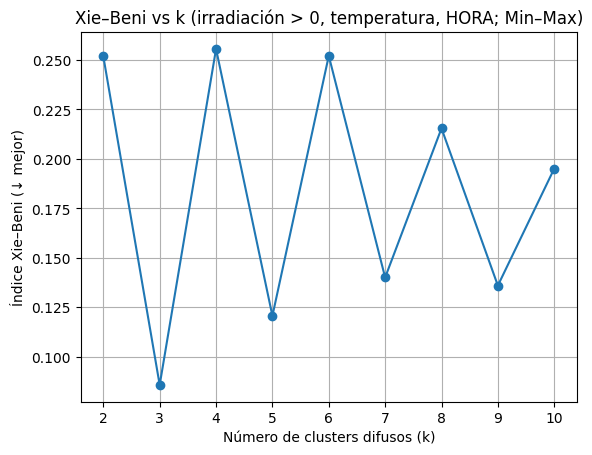

In [ ]:
# === Xie–Beni con Fuzzy C-Means (irradiación > 0, T y HORA) + Min–Max (optimizado) ===
!pip -q install scikit-fuzzy

import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
from sklearn.preprocessing import MinMaxScaler
import skfuzzy as fuzz

# --- Configuración ---
CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clean.csv"
K_MIN, K_MAX = 2, 10
m = 2.0                 # fuzzificador (>=1)
error = 1e-5            # tolerancia
maxiter = 1000          # iteraciones máx
RANDOM_STATE = 42


SAMPLE_N = None

# 1) Cargar dataset limpio
df = pd.read_csv(CSV_CLEAN, low_memory=False)

# 2) Detectar columnas (renombradas o NASA) y tiempo
cols_ren, cols_nasa = ["irradiancia_kWh_m2_h", "t2m_C"], ["ALLSKY_SFC_SW_DWN", "T2M"]
if set(cols_ren).issubset(df.columns):
    IRR, T2M = cols_ren
elif set(cols_nasa).issubset(df.columns):
    IRR, T2M = cols_nasa
else:
    raise KeyError(f"No encuentro {cols_ren} ni {cols_nasa}. Columnas: {list(df.columns)}")

time_col = "datetime_bogota" if "datetime_bogota" in df.columns else ("datetime_utc" if "datetime_utc" in df.columns else None)
if time_col is None:
    raise KeyError("No encuentro columna de tiempo ('datetime_bogota' o 'datetime_utc').")

# 3) Tipos correctos y filtrado horas sin sol
df[IRR] = pd.to_numeric(df[IRR], errors="coerce")
df[T2M]  = pd.to_numeric(df[T2M], errors="coerce")
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df.dropna(subset=[IRR, T2M, time_col], inplace=True)
df = df[df[IRR] > 0].copy()             # quitar noche
df["hour"] = df[time_col].dt.hour.astype(np.int16)

# 4) Features y normalización Min–Max (float32)
FEATURES = [IRR, T2M, "hour"]
X = df[FEATURES].to_numpy(dtype=np.float32)
Xs = MinMaxScaler().fit_transform(X).astype(np.float32)

# 5) Muestreo opcional para FCM
if SAMPLE_N is not None and len(Xs) > SAMPLE_N:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(Xs), size=SAMPLE_N, replace=False)
    Xs_eval = Xs[idx]
else:
    Xs_eval = Xs

Xsf = Xs_eval.T  # shape: (3, n)

def xie_beni_index(X_norm_fs, cntr, u, m=2.0, eps=1e-12):
    """
    X_norm_fs: (f, n)  | cntr: (k, f)  | u: (k, n)
    X_norm_fs y cntr deben estar en el mismo espacio normalizado (Min–Max).
    """
    Xn = X_norm_fs.T        # (n, f)
    k = cntr.shape[0]
    n = Xn.shape[0]

    # Distancias cuadradas de cada punto a cada centroide: (k, n)
    d2 = np.empty((k, n), dtype=np.float32)
    for i in range(k):
        diff = Xn - cntr[i]
        d2[i] = np.sum(diff*diff, axis=1, dtype=np.float32)

    num = np.sum((u**m) * d2, dtype=np.float64)

    # Distancia mínima entre centroides
    min_dist2 = np.inf
    for i in range(k):
        for j in range(i+1, k):
            dist2 = np.sum((cntr[i] - cntr[j])**2, dtype=np.float64)
            if dist2 < min_dist2:
                min_dist2 = dist2

    min_dist2 = max(min_dist2, eps)
    return float(num / (n * min_dist2))

#  Barrido de K y cálculo de XB
k_vals, xb_scores = [], []
best_k, best_xb = None, np.inf

t0 = time.perf_counter()
for k in range(K_MIN, K_MAX+1):
    t_k = time.perf_counter()
    # Fuzzy C-Means
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data=Xsf, c=k, m=m, error=error, maxiter=maxiter, init=None, seed=RANDOM_STATE
    )
    xb = xie_beni_index(Xsf, cntr, u, m=m)
    k_vals.append(k); xb_scores.append(xb)
    if xb < best_xb:
        best_xb, best_k = xb, k
    print(f"k={k}: Xie–Beni={xb:.6f}  |  t={time.perf_counter()-t_k:.2f}s")

print(f"⏱️ Tiempo total: {time.perf_counter()-t0:.2f}s")
print(f"\n✅ BEST_K (Xie–Beni) = {best_k}  |  XB={best_xb:.6f}  (↓ mejor)")

# 7) Gráfica
plt.figure()
plt.plot(k_vals, xb_scores, marker="o")
plt.xlabel("Número de clusters difusos (k)")
plt.ylabel("Índice Xie–Beni (↓ mejor)")
plt.title("Xie–Beni vs k (irradiación > 0, temperatura, HORA; Min–Max)")
plt.grid(True)
plt.show()



📍 Centroides (escala real):
         irradiancia_kWh_m2_h    t2m_C     hour
cluster                                        
0                  589.317505  17.6639  11.2753
1                  179.852295  15.9881  15.7225
2                  205.553406  12.6982   6.9814

✅ K-Means con K=3 guardado en: /content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clusters_k3.csv
✅ Centroides guardados en: /content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_centroides_k3.csv


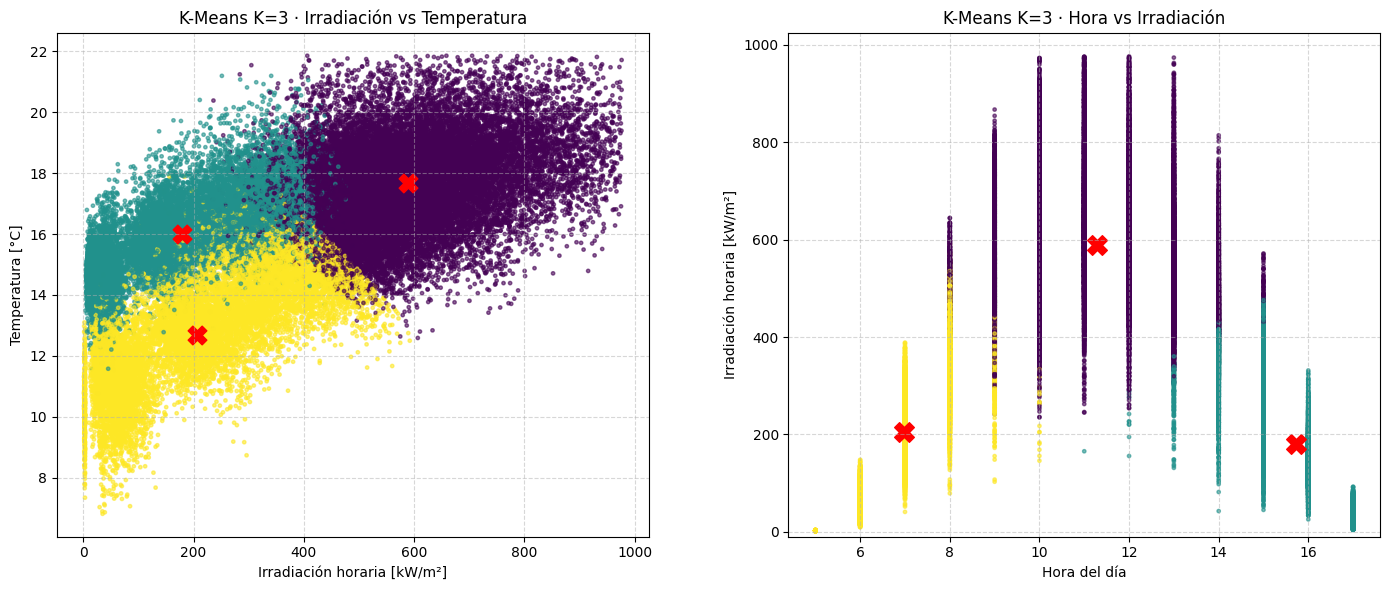

In [ ]:
# === K-Means K=3 (irradiación > 0, T y HORA directa) + Min–Max con subplots ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# --- Configuración ---
CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clean.csv"
OUT_PATH  = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_clusters_k3.csv"
OUT_CENTR = "/content/drive/MyDrive/Colab Notebooks/nasa_power_hourly_11y_bogota_centroides_k3.csv"
K = 3
RANDOM_STATE = 42

# 1) Cargar dataset limpio
df = pd.read_csv(CSV_CLEAN, low_memory=False)

# 2) Detectar columnas
cols_ren, cols_nasa = ["irradiancia_kWh_m2_h", "t2m_C"], ["ALLSKY_SFC_SW_DWN", "T2M"]
if set(cols_ren).issubset(df.columns):
    IRR, T2M = cols_ren
elif set(cols_nasa).issubset(df.columns):
    IRR, T2M = cols_nasa
else:
    raise KeyError(f"No encuentro columnas {cols_ren} ni {cols_nasa}. Columnas: {list(df.columns)}")

time_col = "datetime_bogota" if "datetime_bogota" in df.columns else ("datetime_utc" if "datetime_utc" in df.columns else None)
if time_col is None:
    raise KeyError("No encuentro columna de tiempo ('datetime_bogota' o 'datetime_utc').")

# 3) Tipos correctos y filtrado irradiancia > 0
df[IRR] = pd.to_numeric(df[IRR], errors="coerce")
df[T2M] = pd.to_numeric(df[T2M], errors="coerce")
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df.dropna(subset=[IRR, T2M, time_col], inplace=True)
df = df[df[IRR] > 0].copy()

# 4) Hora directa
df["hour"] = df[time_col].dt.hour.astype(np.int16)

# 5) Features y normalización Min–Max
FEATURES = [IRR, T2M, "hour"]
X = df[FEATURES].to_numpy(dtype=np.float32)
scaler = MinMaxScaler()
Xs = scaler.fit_transform(X).astype(np.float32)

# 6) K-Means
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(Xs)
df["cluster"] = labels.astype(np.int16)

# 7) Centroides desnormalizados
centroids_real = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES
).round(4)
centroids_real.index.name = "cluster"

print("📍 Centroides (escala real):")
print(centroids_real)

df.to_csv(OUT_PATH, index=False)
centroids_real.to_csv(OUT_CENTR)
print(f"\n✅ K-Means con K={K} guardado en: {OUT_PATH}")
print(f"✅ Centroides guardados en: {OUT_CENTR}")

# === Visualización en subplots ===
fig, axes = plt.subplots(1, 2, figsize=(14,6))   # 1 fila, 2 columnas

# --- Gráfica 1: Irradiancia vs Temperatura ---
axes[0].scatter(df[IRR], df[T2M], c=df["cluster"], s=6, alpha=0.6)
axes[0].scatter(centroids_real[IRR], centroids_real[T2M], marker="X", s=180, c="red")
axes[0].set_xlabel("Irradiación horaria [kW/m²]")
axes[0].set_ylabel("Temperatura [°C]")
axes[0].set_title(f"K-Means K={K} · Irradiación vs Temperatura")
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Gráfica 2: Hora vs Irradiancia ---
axes[1].scatter(df["hour"], df[IRR], c=df["cluster"], s=6, alpha=0.6)
axes[1].scatter(centroids_real["hour"], centroids_real[IRR], marker="X", s=200, c="red")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Irradiación horaria [kW/m²]")
axes[1].set_title(f"K-Means K={K} · Hora vs Irradiación")
axes[1].set_ylim(-10, None)
axes[1].grid(True, linestyle="--", alpha=0.5)

# --- Ajustar espacio entre gráficas ---
plt.tight_layout(w_pad=5.0)  # espacio horizontal entre subplots
plt.show()


Parábola ajustada (forma estándar):
Y = -20.757896 X² + 468.344934 X + -2052.411185

Forma de vértice:
Y = -20.757896 (X - 11.281127)² + 589.318210

Vértice: (h, k) = (11.281127, 589.318210)
R² (sobre centroides): 1.000000


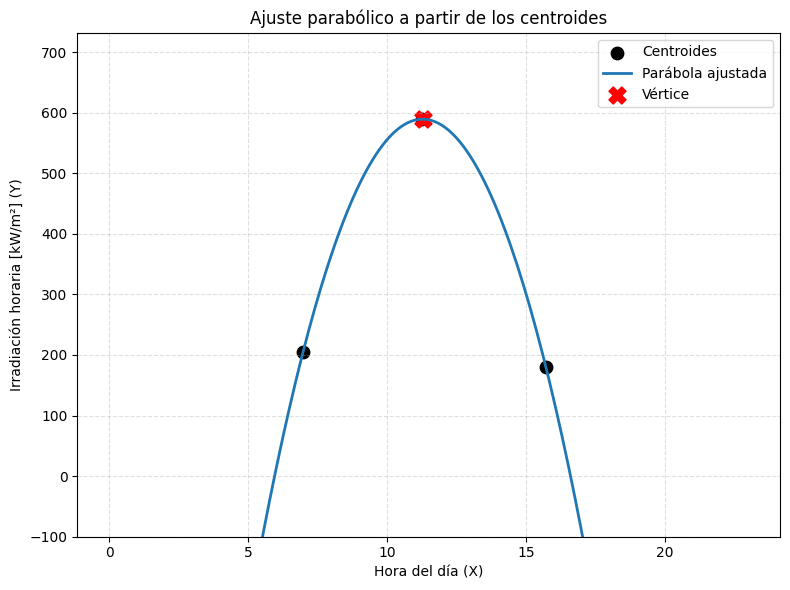

In [ ]:
# === Parabola Y = aX^2 + bX + c a partir de los centroides (X=hour, Y=irradiancia) ===
import numpy as np
import matplotlib.pyplot as plt

# Detectar la columna de irradiancia en centroids_real
if "irradiancia_kWh_m2_h" in centroids_real.columns:
    IRR = "irradiancia_kWh_m2_h"
elif "ALLSKY_SFC_SW_DWN" in centroids_real.columns:
    IRR = "ALLSKY_SFC_SW_DWN"
else:
    raise KeyError("No encuentro columna de irradiancia en centroids_real. Esperaba 'irradiancia_kWh_m2_h' o 'ALLSKY_SFC_SW_DWN'.")

# 1) Extraer (X,Y) de los centroides
X = centroids_real["hour"].values.astype(float)
Y = centroids_real[IRR].values.astype(float)

# Ordenar por X para graficar más prolijo
ord_idx = np.argsort(X)
X, Y = X[ord_idx], Y[ord_idx]

# 2) Ajuste cuadrático Y = aX^2 + bX + c
a, b, c = np.polyfit(X, Y, deg=2)

# 3) Forma de vértice Y = a (X - h)^2 + k
h = -b / (2*a)
k = a*h*h + b*h + c

# 4) Métrica R²
Y_hat = a*X**2 + b*X + c
ss_res = np.sum((Y - Y_hat)**2)
ss_tot = np.sum((Y - np.mean(Y))**2)
R2 = 1 - ss_res/ss_tot if ss_tot > 0 else 1.0

# 5) Mostrar ecuaciones
print("Parábola ajustada (forma estándar):")
print(f"Y = {a:.6f} X² + {b:.6f} X + {c:.6f}")
print("\nForma de vértice:")
print(f"Y = {a:.6f} (X - {h:.6f})² + {k:.6f}")
print(f"\nVértice: (h, k) = ({h:.6f}, {k:.6f})")
print(f"R² (sobre centroides): {R2:.6f}")

# 6) Gráfica: Hora vs Irradiancia con la parábola
x_plot = np.linspace(0, 23, 200)
y_plot = a*x_plot**2 + b*x_plot + c

plt.figure(figsize=(8,6))
plt.scatter(X, Y, c="black", s=80, label="Centroides")
plt.plot(x_plot, y_plot, linewidth=2, label="Parábola ajustada")
plt.scatter([h], [k], c="red", marker="X", s=150, label="Vértice")

plt.xlabel("Hora del día (X)")
plt.ylabel("Irradiación horaria [kW/m²] (Y)")
plt.title("Ajuste parabólico a partir de los centroides")
plt.ylim(-100, None)   # 👈 límite inferior en -100
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


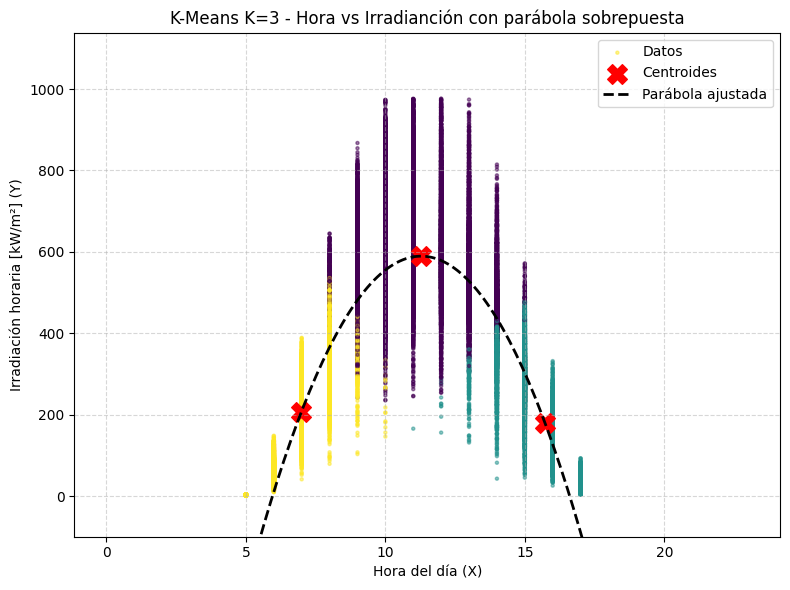

In [ ]:
# === Gráfica Hora vs Irradiancia con clusters, centroides y parábola ajustada (Y desde -100) ===

import numpy as np
import matplotlib.pyplot as plt

# Detectar columna de irradiancia en centroids_real
if "irradiancia_kWh_m2_h" in centroids_real.columns:
    IRR = "irradiancia_kWh_m2_h"
elif "ALLSKY_SFC_SW_DWN" in centroids_real.columns:
    IRR = "ALLSKY_SFC_SW_DWN"
else:
    raise KeyError("No encuentro columna de irradiancia en centroids_real. Esperaba 'irradiancia_kWh_m2_h' o 'ALLSKY_SFC_SW_DWN'.")

# 1) Extraer coordenadas de centroides
Xc = centroids_real["hour"].values.astype(float)
Yc = centroids_real[IRR].values.astype(float)

# Ajustar parábola Y = aX^2 + bX + c
a, b, c = np.polyfit(Xc, Yc, deg=2)

# Generar curva suave
x_plot = np.linspace(0, 23, 200)
y_plot = a*x_plot**2 + b*x_plot + c

# 2) Gráfico
plt.figure(figsize=(8,6))

# Datos clusterizados
plt.scatter(df["hour"], df[IRR], c=df["cluster"], s=5, alpha=0.5, cmap="viridis", label="Datos")

# Centroides
plt.scatter(centroids_real["hour"], centroids_real[IRR], c="red", marker="X", s=200, label="Centroides")

# Parábola ajustada
plt.plot(x_plot, y_plot, "k--", linewidth=2, label="Parábola ajustada")

plt.xlabel("Hora del día (X)")
plt.ylabel("Irradiación horaria [kW/m²] (Y)")
plt.title("K-Means K=3 - Hora vs Irradianción con parábola sobrepuesta")
plt.ylim(-100, None)   # 🔹 Limitar eje Y desde -100
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()




📍 Cortes en el eje X (Y=0): X1 = 5.953, X2 = 16.609


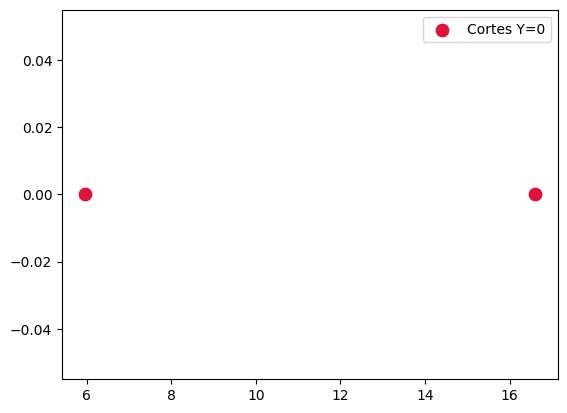

In [ ]:
# === Cortes de la parábola con el eje X (Y=0)  ===
import numpy as np
import matplotlib.pyplot as plt

EPS_A = 1e-12          # tolerancia para considerar a≈0
EPS_DISC = 1e-12       # tolerancia para considerar discriminante≈0
X_MIN, X_MAX = 0.0, 23.0

if abs(a) < EPS_A:
    print("⚠️ a≈0: el ajuste es casi lineal, no es parábola. Resuelvo bX + c = 0 si b≠0.")
    if abs(b) < EPS_A:
        print("❌ b≈0 también: no hay corte definido (constante).")
    else:
        x_lin = -c / b
        print(f"📍 Corte lineal: X = {x_lin:.3f}  (rango horario esperado: {X_MIN}–{X_MAX})")
else:
    disc = b*b - 4*a*c
    if disc < -EPS_DISC:
        print("⚠️ La parábola no corta el eje X (raíces complejas).")
    else:
        # Si es levemente negativo por redondeo, tómalo como 0
        disc = max(disc, 0.0)
        sqrt_disc = np.sqrt(disc)
        x1 = (-b - sqrt_disc) / (2*a)
        x2 = (-b + sqrt_disc) / (2*a)
        x1, x2 = (x1, x2) if x1 <= x2 else (x2, x1)
        print(f"📍 Cortes en el eje X (Y=0): X1 = {x1:.3f}, X2 = {x2:.3f}")

        # Avisos si quedan fuera del rango horario
        if (x1 < X_MIN or x1 > X_MAX) or (x2 < X_MIN or x2 > X_MAX):
            print(f"ℹ️ Aviso: alguna raíz cae fuera del rango horario [{X_MIN}, {X_MAX}]. Interprétalo con cautela.")

        try:
            plt.scatter([x1, x2], [0, 0], c="crimson", s=80, zorder=5, label="Cortes Y=0")
            plt.legend()
            plt.draw()
        except Exception:
            pass



In [ ]:
# === Área física (irradiación ≥ 0) bajo la parábola y = a x^2 + b x + c ===
import numpy as np


# Rango horario por defecto si no hay raíces reales
X_MIN, X_MAX = 0.0, 23.0
EPS_DISC = 1e-12

# 1) Calcular raíces (cortes con Y=0), si existen
disc = b*b - 4*a*c
if disc >= -EPS_DISC:
    disc = max(disc, 0.0)
    sqrt_disc = np.sqrt(disc)
    # Si a≈0, tratar como línea
    if abs(a) < 1e-12:
        # y = b x + c  -> corte único
        if abs(b) < 1e-12:
            x1, x2 = X_MIN, X_MAX
        else:
            x_lin = -c / b
            x1, x2 = sorted([x_lin, X_MAX]) if X_MIN <= x_lin <= X_MAX else (X_MIN, X_MAX)
    else:
        r1 = (-b - sqrt_disc) / (2*a)
        r2 = (-b + sqrt_disc) / (2*a)
        x1, x2 = (r1, r2) if r1 <= r2 else (r2, r1)
else:
    # Sin raíces reales: integrar en todo el día
    x1, x2 = X_MIN, X_MAX

# 2) Integración numérica recortando a 0 (irradiación no negativa)
xp = np.linspace(max(X_MIN, x1), min(X_MAX, x2), 400)
yp = a*xp**2 + b*xp + c
area_fisica = np.trapz(np.maximum(yp, 0.0), xp)  # kWh/m²

print(f"🔆 Área física (y≥0) entre X={xp[0]:.3f} y X={xp[-1]:.3f}: {area_fisica:.3f} Wh/m²")



🔆 Área física (y≥0) entre X=5.953 y X=16.609: 4186.674 Wh/m²


/tmp/ipython-input-1839039718.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_fisica = np.trapz(np.maximum(yp, 0.0), xp)  # kWh/m²


In [ ]:
# === Cálculo simple de HSP y CF ===

# Datos de entrada
E_D = area_fisica   # Energía diaria recibida [Wh/m²]
G_0 = 1000       # Irradiancia de referencia [W/m²]
H_total = 24.0   # Horas del día

# Hora Solar Pico (HSP)
HSP = E_D / G_0   # en horas

# Factor de capacidad (CF)
CF = HSP / H_total
CF_pct = CF * 100

print(f"🔆 Hora Solar Pico (HSP): {HSP:.3f} h")
print(f"⚡ Factor de Capacidad (CF): {CF:.4f} ({CF_pct:.2f}%)")


🔆 Hora Solar Pico (HSP): 4.187 h
⚡ Factor de Capacidad (CF): 0.1744 (17.44%)
